In [ ]:
import os
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from PIL import UnidentifiedImageError  

from tensorflow import keras
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Activation, GlobalAveragePooling2D, RandomFlip, RandomRotation, RandomZoom
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras import regularizers
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from collections import Counter

base_path = 'DATA/Dataset'
target_size = (256, 256)

def load_dataset(split):
    images = []
    labels = []

    split_path = os.path.join(base_path, split)

    for fname in os.listdir(split_path):
        fpath = os.path.join(split_path, fname)
        
        try:
            # Tenta carregar a imagem
            img = image.load_img(fpath, target_size=target_size)
            
            # Se a imagem for carregada com sucesso, processa ela
            img_array = image.img_to_array(img)
            img_array = img_array / 255.0
            
            label = 1 if 'explosive' in fname.lower() else 0
            
            images.append(img_array)
            labels.append(label)

        except UnidentifiedImageError:
            print(f"Pulando o arquivo '{fpath}' porque ele não é uma imagem válida ou está corrompido.")
            continue
        except Exception as e:
            print(f"Ocorreu um erro desconhecido com o arquivo '{fpath}': {e}")
            continue

    if not images:
        print(f"Nenhuma imagem válida encontrada no diretório '{split_path}'.")
        return tf.data.Dataset.from_tensors((tf.constant([]), tf.constant([])))

    images_np = np.array(images, dtype=np.float32)
    labels_np = np.array(labels, dtype=np.int32)
    
    images_tensor = tf.convert_to_tensor(images_np, dtype=tf.float32)
    labels_tensor = tf.convert_to_tensor(labels_np, dtype=tf.int32)
    
    dataset = tf.data.Dataset.from_tensor_slices((images_tensor, labels_tensor))
    dataset = dataset.shuffle(buffer_size=len(images)).batch(32).prefetch(tf.data.AUTOTUNE)
    print(Counter(labels))

    return dataset

train_dataset = load_dataset('train')
val_dataset = load_dataset('val')
test_dataset = load_dataset('test')

Pulando o arquivo 'Dataset\train\BENZOIMIDAZOL-SP-MP2-DEF2-TZVP_6.jpg' porque ele não é uma imagem válida ou está corrompido.
Counter({1: 1350, 0: 1139})
Counter({1: 330, 0: 210})
Counter({1: 11, 0: 7})


In [ ]:
strategy = tf.distribute.get_strategy()

with strategy.scope():
    model = Sequential()
    
    model.add(Input(shape=(256, 256, 3)))
    
    model.add(RandomFlip('horizontal'))
    model.add(RandomRotation(0.05))  
    model.add(RandomZoom(0.05))     

    model.add(Conv2D(16, (3,3), strides=1, padding='same', kernel_regularizer=regularizers.l2(0.0001))) # L2 
    model.add(Activation('relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2,2), padding='same'))
    model.add(Dropout(0.5)) # Dropout 
    
    model.add(Conv2D(32, (3,3), padding='same', kernel_regularizer=regularizers.l2(0.0001))) 
    model.add(Activation('relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2,2), padding='same'))
    model.add(Dropout(0.5)) # Dropout 

    model.add(Conv2D(64, (3,3), padding='same', kernel_regularizer=regularizers.l2(0.0001))) 
    model.add(Activation('relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2,2), padding='same'))
    model.add(Dropout(0.5)) # Dropout 

    model.add(GlobalAveragePooling2D())
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.7)) # Dropout 
    model.add(Dense(1, activation='sigmoid'))

    optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

In [7]:
# Callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    mode='min',
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    'models/CNN-ESP.keras',
    monitor='val_loss',
    save_best_only=True,
    mode='min'
)

# Train the model with tf.data.Dataset
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=50,
    callbacks=[early_stopping, checkpoint]
)

Epoch 1/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 124s 1s/step - accuracy: 0.6320 - loss: 0.6806 - val_accuracy: 0.3889 - val_loss: 0.7433
Epoch 2/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 116s 1s/step - accuracy: 0.8718 - loss: 0.3818 - val_accuracy: 0.3889 - val_loss: 0.7258
Epoch 3/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 115s 1s/step - accuracy: 0.9317 - loss: 0.2854 - val_accuracy: 0.3889 - val_loss: 0.6846
Epoch 4/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 113s 1s/step - accuracy: 0.9389 - loss: 0.2503 - val_accuracy: 0.4444 - val_loss: 0.6474
Epoch 5/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 115s 1s/step - accuracy: 0.9598 - loss: 0.1926 - val_accuracy: 0.4870 - val_loss: 0.6009
Epoch 6/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 114s 1s/step - accuracy: 0.9679 - loss: 0.1684 - val_accuracy: 0.7778 - val_loss: 0.5270
Epoch 7/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 111s 1s/step - accuracy: 0.9707 - loss: 0.1526 - val_accuracy: 0.8574 - val_loss: 0.4497
Epoch 8/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 116s 1s/step - accuracy: 0.9763 - loss: 0.1298 - val_accuracy: 0.8333 - v

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 929ms/step - accuracy: 1.0000 - loss: 0.0795
Test Loss: 0.0795
Test Accuracy: 1.0000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00        11

    accuracy                           1.00        18
   macro avg       1.00      1.00      1.00        18
weighted avg       1.00      1.00      1.00        18



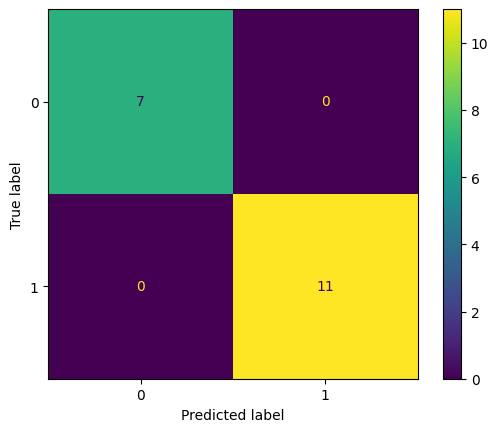

In [8]:
# Load the best model automatically saved by ModelCheckpoint
model = load_model('models/CNN-ESP.keras')

# Evaluation on the test set
loss, accuracy = model.evaluate(test_dataset)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

y_true = []
y_pred_prob = []

for batch_images, batch_labels in test_dataset:
    preds = model.predict(batch_images)
    y_pred_prob.extend(preds.flatten())
    y_true.extend(batch_labels.numpy())

y_true = np.array(y_true)
y_pred_prob = np.array(y_pred_prob)
y_pred = (y_pred_prob > 0.5).astype(int)

cm = confusion_matrix(y_true, y_pred)
print(classification_report(y_true, y_pred))

ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.show()

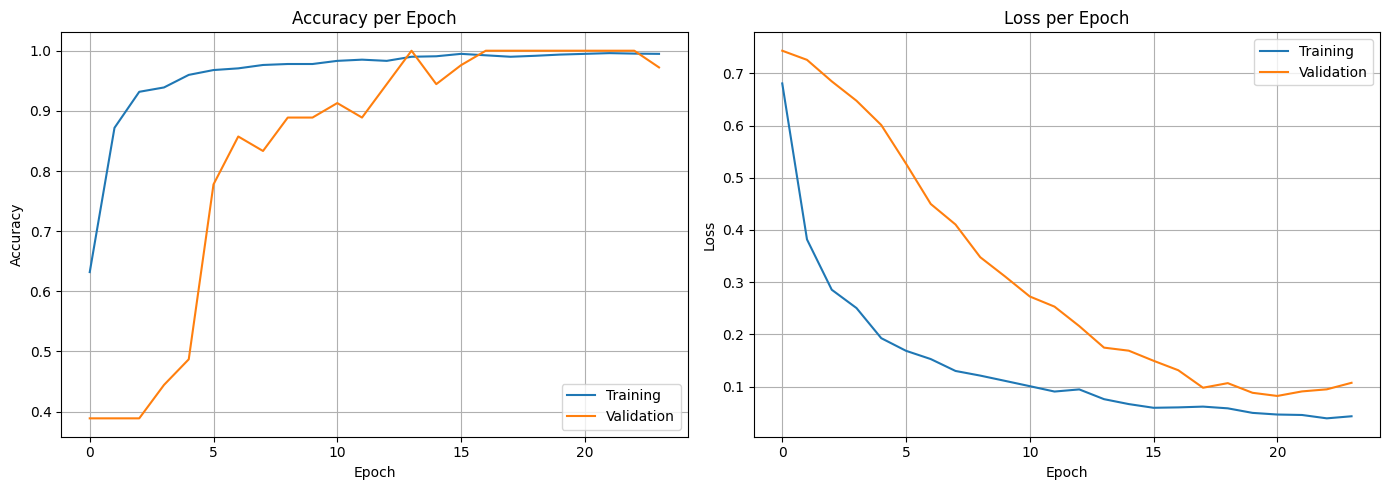

In [9]:
# === Plot training history (accuracy and loss) ===
plt.figure(figsize=(14, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [10]:
# Load the best model automatically saved by ModelCheckpoint
model = load_model('models/CNN-ESP.keras')
# Evaluation on the training set
loss, accuracy = model.evaluate(train_dataset)
print(f"Train Loss: {loss:.4f}")
print(f"Train Accuracy: {accuracy:.4f}")

# Evaluation on the validation set
loss, accuracy = model.evaluate(val_dataset)
print(f"Val Loss: {loss:.4f}")
print(f"Val Accuracy: {accuracy:.4f}")

# Evaluation on the validation set
loss, accuracy = model.evaluate(test_dataset)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

78/78 ━━━━━━━━━━━━━━━━━━━━ 15s 185ms/step - accuracy: 1.0000 - loss: 0.0774
Train Loss: 0.0774
Train Accuracy: 1.0000
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 186ms/step - accuracy: 1.0000 - loss: 0.0819
Val Loss: 0.0819
Val Accuracy: 1.0000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 1.0000 - loss: 0.0795
Test Loss: 0.0795
Test Accuracy: 1.0000
